In [1]:
import json
from collections import OrderedDict

import gensn.distributions as G
import torch
import torch.distributions as D
from sklearn.datasets import make_spd_matrix

from task_transfer.ml_lib.loss_criteria import mc_marginal_nll, mc_marginal_nll_detailed
from task_transfer.utils.math_utils import is_pos_def
from task_transfer.utils.utils import dict_product

import matplotlib.pyplot as plt
import seaborn as sns

seed = 42
torch.manual_seed(seed)

# Define constants

In [2]:
prior_dim = 100
conditional_dim = 2
mc_sample_size = 1000
sample_size = 10

# Define true distributions

In [3]:
# construct prior and conditional of the generative model
mu_prior = torch.rand((prior_dim,))
cov_prior = torch.eye(prior_dim)
prior = G.IndependentNormal(loc=mu_prior, scale=torch.sqrt(cov_prior.diag()))
mu_conditional = torch.nn.Linear(prior_dim, conditional_dim)
mu_conditional.weight.data = torch.rand(conditional_dim, prior_dim)
mu_conditional.bias.data = torch.rand(conditional_dim)
cov_conditional = torch.Tensor(make_spd_matrix(conditional_dim))
conditional = G.TrainableDistributionAdapter(
    D.MultivariateNormal, loc=mu_conditional, covariance_matrix=cov_conditional
)
# construct the marginal analytically
mu_marginal = mu_prior @ mu_conditional.weight.data.T + mu_conditional.bias.data
marginal_cov = (
    mu_conditional.weight.data @ cov_prior @ mu_conditional.weight.data.T
    + cov_conditional
)
marginal = G.TrainableDistributionAdapter(
    D.MultivariateNormal, loc=mu_marginal, covariance_matrix=marginal_cov
)
# construct the joint
joint = G.Joint(prior, conditional)

# Sample data to compute log prob

In [4]:
sample = marginal.sample((sample_size,))

# Implement marginalization

In [5]:
prior_sample = joint.prior.rsample((mc_sample_size,))
conditional_dist = joint.conditional.distribution(cond=prior_sample.unsqueeze(1))
conditional_ll = conditional_dist.log_prob(sample)
marginal_ll = torch.logsumexp(conditional_ll, dim=0) - torch.log(
    torch.tensor(conditional_ll.shape[0])
)

In [6]:
true_marginal_ll = marginal.log_prob(sample)

In [7]:
marginal_ll.mean()

tensor(-5.9526, grad_fn=<MeanBackward0>)

In [8]:
true_marginal_ll.mean()

tensor(-5.9676)

In [9]:
new_sample = torch.randn_like(sample)

In [10]:
new_conditional_ll = conditional_dist.log_prob(new_sample)
new_marginal_ll = torch.logsumexp(new_conditional_ll, dim=0) - torch.log(
    torch.tensor(new_conditional_ll.shape[0])
)
new_true_marginal_ll = marginal.log_prob(new_sample)

In [11]:
new_marginal_ll.mean(), new_true_marginal_ll.mean()

(tensor(-136.5549, grad_fn=<MeanBackward0>), tensor(-17.5483))

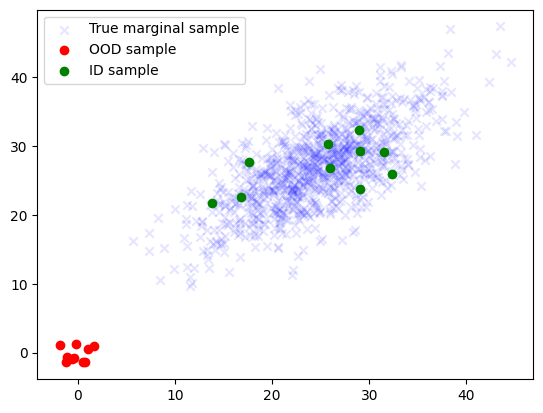

In [23]:
true_marg_samples = marginal.sample((1000,))
plt.scatter(true_marg_samples[:, 0], true_marg_samples[:, 1], marker="x",color="blue", label="True marginal sample", alpha=0.1)
plt.scatter(new_sample[:, 0], new_sample[:, 1], color="red", label="OOD sample")
plt.scatter(sample[:, 0], sample[:, 1], color="green", label="ID sample")
plt.legend()

In [24]:
conditional_dist.loc

tensor([[[32.1710, 33.5337]],

        [[32.7728, 30.3501]],

        [[24.5000, 31.3436]],

        ...,

        [[18.9468, 18.9139]],

        [[24.7373, 25.1885]],

        [[23.9469, 29.6135]]], grad_fn=<ExpandBackward0>)

In [26]:
marginal.loc

tensor([24.4891, 26.7184])

In [28]:
conditional_dist.loc.shape

torch.Size([1000, 1, 2])

In [30]:
conditional_dist.covariance_matrix[0][0]

tensor([[ 2.4146, -0.4076],
        [-0.4076,  0.5412]])

In [31]:
marginal_cov

tensor([[34.0195, 21.2443],
        [21.2443, 32.6358]])

In [33]:
import numpy as np
from task_transfer.utils.insilico_stimuli import generate_gabors

prior_dim = 45
conditional_dim = 144
# construct prior and conditional of the generative model
mu_prior = torch.rand((prior_dim,))
cov_prior = torch.eye(prior_dim)
prior = G.IndependentNormal(loc=mu_prior, scale=torch.sqrt(cov_prior.diag()))
mu_conditional = torch.nn.Linear(prior_dim, conditional_dim)
x_phi = torch.linspace(0, np.pi, steps=prior_dim + 1)[:-1]
gabor_params = dict(
    {
        "canvas_size": [12, 12],
        "sizes": [10],
        "spatial_frequencies": [1 / 3],
        "contrasts": [1.0],
        "grey_levels": [0.0],
        "eccentricities": [0.0],
        "locations": [[6, 6]],
        "phases": [np.pi / 2],
        "relative_sf": False,
    },
)
x_pfs = torch.Tensor(
    generate_gabors(orientations=x_phi.tolist(), gabor_params=gabor_params)
)
mu_conditional.weight.data = x_pfs.view(x_pfs.shape[0], -1).T
mu_conditional.bias.data = torch.zeros(conditional_dim)

cov_x_z = torch.Tensor(make_spd_matrix(conditional_dim))
# C = torch.randn((conditional_dim, conditional_dim)) / 10
# L = torch.tril(C)
# cov_x_z = L @ L.T + 1e-4 * torch.eye(conditional_dim)
# cov_x_z = cov_x_z @ cov_x_z.T + 1e-4 * torch.eye(conditional_dim)
conditional = G.TrainableDistributionAdapter(
    D.MultivariateNormal, loc=mu_conditional, covariance_matrix=cov_x_z
)
joint = G.Joint(prior=prior, conditional=conditional)
marginal_mu = mu_prior @ mu_conditional.weight.data.T + mu_conditional.bias.data
marginal_cov = mu_conditional.weight.data @ cov_prior @ mu_conditional.weight.data.T + cov_x_z
marginal = G.TrainableDistributionAdapter(
    D.MultivariateNormal, loc=marginal_mu, covariance_matrix=marginal_cov
)

In [44]:
obs_batch_dim = 128
mc_sample_size = (50_000,)
obs = marginal.sample((obs_batch_dim,))
true_marginal_lp = marginal(obs).mean()
# mc_marginal_lp = mc_marginal_log_likelihood(
#     joint, obs, mc_sample_size=mc_sample_size, reduction="mean"
# )
# data = obs
# prior_sample = joint.prior.rsample(mc_sample_size)
# conditional_dist = joint.conditional.distribution(cond=prior_sample.unsqueeze(1))
# conditional_ll = conditional_dist.log_prob(data)
# marginal_ll = torch.logsumexp(conditional_ll, dim=0) - torch.log(
#     torch.tensor(conditional_ll.shape[0])
# )
marginal_nll, prior_sample, conditional_dist, conditional_ll = (
    mc_marginal_nll_detailed(joint, [obs, obs], 0, mc_sample_size)
)
marginal_ll = -marginal_nll.mean()
error = torch.abs(marginal_ll - true_marginal_lp) / conditional_dim

: 

In [ ]:
error

tensor(0.9320, grad_fn=<DivBackward0>)

In [ ]:
marginal_ll

tensor(-296.3004, grad_fn=<NegBackward0>)

In [ ]:
true_marginal_lp

tensor(-162.0879)

In [ ]:
exp_prior = G.IndependentExponential(rate=torch.ones(prior_dim))
exp_prior_samples = exp_prior.sample(mc_sample_size)
conditional_dist = joint.conditional.distribution(cond=exp_prior_samples.unsqueeze(1))
conditional_ll = conditional_dist.log_prob(obs)
marginal_ll = torch.logsumexp(conditional_ll, dim=0) - torch.log(
    torch.tensor(conditional_ll.shape[0])
)

In [43]:
marginal_ll

tensor([ -398.7205,  -973.5718,  -531.6816,  -268.2181,  -618.5480,  -516.5795,
         -509.0352, -1863.1467,  -309.7722, -1278.0311,  -236.6594,  -580.1712,
        -1467.3365,  -796.4244,  -480.7362,  -897.2314,  -318.7858, -1547.0488,
         -338.0911,  -478.4553,  -551.2625,  -498.5635, -1040.4243, -1229.8260,
         -343.9295,  -955.7051, -1064.2903,  -920.8376, -1074.8848,  -307.1320,
         -253.0633, -1474.3168,  -841.6894,  -740.2690,  -390.8441, -1434.6904,
         -532.6202,  -378.1066, -1164.5995,  -531.9427,  -457.5437,  -577.0530,
        -1233.7598,  -450.8421, -2094.9248, -1034.6433, -1103.2986,  -392.4288,
         -336.2443, -1750.7036,  -470.9305,  -878.1696, -2641.7837,  -795.3925,
        -1301.4362, -4129.8472,  -860.0774, -2159.5864,  -799.2545, -1263.9619,
        -2904.4805,  -307.4818, -1763.3801,  -697.3043, -1705.9034,  -691.4251,
         -430.1851,  -361.4364, -1181.2101,  -473.2527,  -249.7806,  -273.7185,
         -839.0821,  -484.6348,  -714.83